In [ ]:
import os
import sys
import math
import json
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("../data/Impact of Lifestyle Factors on Student Productivity (Responses).csv")

--- INSIGHT 1: Top Productivity Killers ---
Negative_Factor
Excessive social media / screen time    36.0
Poor sleep                              17.6
Unhealthy diet                          16.0
Stress and anxiety                      16.0
Lack of exercise                        14.4
Name: proportion, dtype: float64


/tmp/ipykernel_13713/1753134731.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_factors.values, y=top_factors.index, palette="Reds_r")


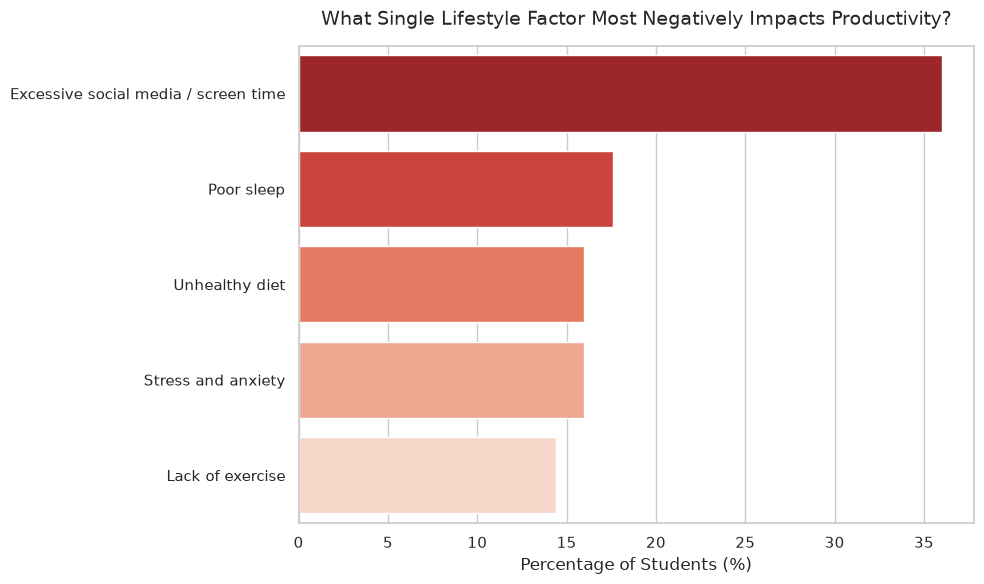

In [11]:


# Set visual style
sns.set_theme(style="whitegrid")

# Drop rows where the target productivity score is missing
df = df.dropna(subset=['Q31. How would you rate your overall academic productivity on a typical day?'])

# Rename columns for easier access
cols_to_analyze = {
    'Q34. Which single lifestyle factor do you think most negatively impacts your productivity?': 'Negative_Factor',
    'Q32. Do you often procrastinate or delay starting academic tasks?': 'Procrastination',
    'Q24. How often do you feel stressed or overwhelmed due to academic pressure?': 'Stress_Level'
}
df = df.rename(columns=cols_to_analyze)


# ---------------------------------------------------------
# Insight 1: The Biggest Self-Reported Culprits
# ---------------------------------------------------------
print("--- INSIGHT 1: Top Productivity Killers ---")
top_factors = df['Negative_Factor'].value_counts(normalize=True).head(5) * 100
print(top_factors)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_factors.values, y=top_factors.index, palette="Reds_r")
plt.title('What Single Lifestyle Factor Most Negatively Impacts Productivity?', fontsize=14, pad=15)
plt.xlabel('Percentage of Students (%)', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()





--- INSIGHT 2: Procrastination Frequency ---
Procrastination
Never             8.0
Rarely           15.2
Sometimes        40.0
Often            20.8
Almost always    16.0
Name: proportion, dtype: float64


/tmp/ipykernel_13713/2428288242.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=proc_counts.index, y=proc_counts.values, palette="Blues")


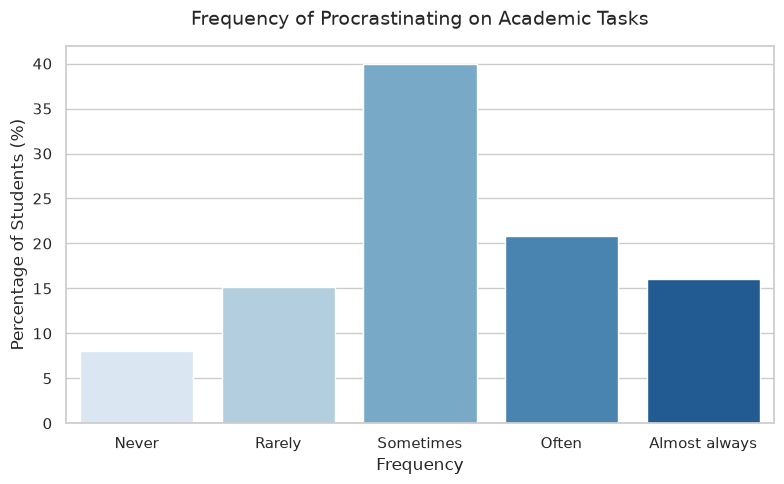

In [12]:
# ---------------------------------------------------------
# Insight 2: The Procrastination Epidemic
# ---------------------------------------------------------
print("\n--- INSIGHT 2: Procrastination Frequency ---")
proc_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Almost always']
proc_counts = df['Procrastination'].value_counts(normalize=True) * 100
proc_counts = proc_counts.reindex(proc_order) # Reorder for logical flow
print(proc_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=proc_counts.index, y=proc_counts.values, palette="Blues")
plt.title('Frequency of Procrastinating on Academic Tasks', fontsize=14, pad=15)
plt.ylabel('Percentage of Students (%)', fontsize=12)
plt.xlabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()




--- INSIGHT 3: Academic Stress Levels ---
Stress_Level
Never             7.2
Rarely           15.2
Sometimes        32.8
Often            27.2
Almost always    17.6
Name: proportion, dtype: float64


/tmp/ipykernel_13713/1306460884.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stress_counts.index, y=stress_counts.values, palette="Purples")


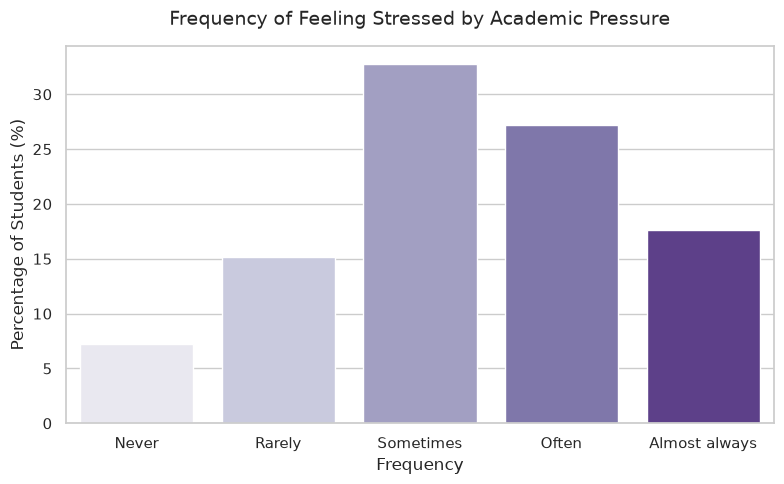

In [13]:

# ---------------------------------------------------------
# Insight 3: Academic Stress Levels
# ---------------------------------------------------------
print("\n--- INSIGHT 3: Academic Stress Levels ---")
stress_order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Almost always']
stress_counts = df['Stress_Level'].value_counts(normalize=True) * 100
stress_counts = stress_counts.reindex(stress_order) # Reorder for logical flow
print(stress_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=stress_counts.index, y=stress_counts.values, palette="Purples")
plt.title('Frequency of Feeling Stressed by Academic Pressure', fontsize=14, pad=15)
plt.ylabel('Percentage of Students (%)', fontsize=12)
plt.xlabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()